In [6]:
import json, sys, re, os

root = '/home/jovyan/workspace/TQP-Vortex/'

dat = '2025-09-07'
SF = 100

def load_json_total_breakdown(dat, SF, qid, mode):
    gpu_tots, io_tots, other_tots, gpu_non_pipe = ([] for _ in range(4))
    path = f"experiments/results/{dat}/{mode}/SF{SF}_{qid}.json"
    try:
        with open(os.path.join(root, path), encoding='utf-8') as f:
            data = json.load(f)
    except Exception as e:
        print(f"Error reading {path}: {e}", file=sys.stderr)
    tot = next(v for k, v in data.items() if re.match(r"Query", k))
    ops = {k: v for k, v in data.items() if re.match(r"^[a-z]{2,} \d+$", k)}

    ops = {k: v for k, v in ops.items() if not (k.startswith('scan') or k.startswith('output'))}
    # ops = {k: v for k, v in ops.items()}
    most_others = {}
    most_runtimes = {}
    for op, time in ops.items():
        components = {k: v for k, v in data.items() if re.match(rf"{re.escape(op)} .*apply op.*$", k) or re.match(rf"{re.escape(op)} .* transfer .*$", k)}
        most_others[op] = time  - sum([i['total'] for i in components.values()])
        most_runtimes[op] = time['total']

    sorted_runtime =  dict(sorted(most_runtimes.items(), key=lambda item: item[1], reverse=True))
    print(sorted_runtime)
    print(sum(sorted_runtime.values()))
    sorted_ops = dict(sorted(most_others.items(), key=lambda item: item[1], reverse=True))
    print(sorted_ops)
    total_sorted_ops = sum(sorted_ops.values())
    print(f"Sum of others values: {total_sorted_ops}")

load_json_total_breakdown(dat, SF, 8, 'zero_copy_everything')

TypeError: unsupported operand type(s) for -: 'dict' and 'float'

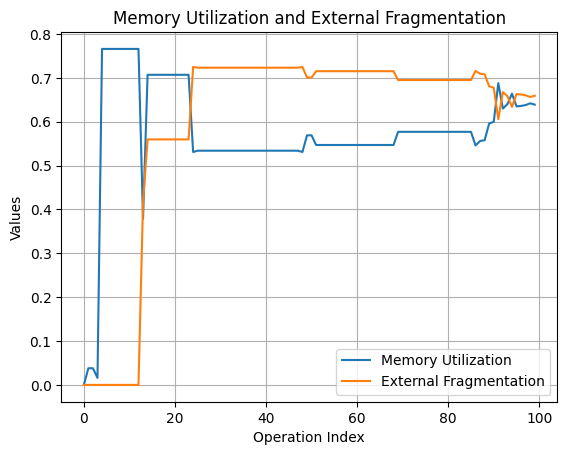

In [ ]:
import json, sys, re, os
import matplotlib.pyplot as plt
root = '/home/jovyan/workspace/TQP-Vortex/'

dat = '2025-08-26'
SF = 100

def analyze_mem(dat, SF, qid, mode):
    gpu_tots, io_tots, other_tots, gpu_non_pipe = ([] for _ in range(4))
    path = f"experiments/results/{dat}/{mode}/SF{SF}_Q{qid}.json"
    try:
        with open(os.path.join(root, path), encoding='utf-8') as f:
            data = json.load(f)
    except Exception as e:
        print(f"Error reading {path}: {e}", file=sys.stderr)
    
    mem_util = data['mem_util']
    extern_frag = data['mem_ext_frag']

    # Assuming mem_util and extern_frag are lists
    plt.plot(mem_util, label='Memory Utilization')
    plt.plot(extern_frag, label='External Fragmentation')
    plt.title('Memory Utilization and External Fragmentation')
    plt.xlabel('Operation Index')
    plt.ylabel('Values')
    plt.legend()
    plt.grid(True)
    plt.show()
analyze_mem(dat, SF, 21, 'datasize_profile')

In [7]:
import json, sys, re, os

root = '/home/jovyan/workspace/TQP-Vortex/'

dat = '2025-09-24'
SF = 100

def load_json_total_breakdown(dat, SF, qid, mode):
    gpu_tots, io_tots, other_tots, gpu_non_pipe = ([] for _ in range(4))
    path = f"experiments/results/{dat}/{mode}/SF{SF}_{qid}.json"
    try:
        with open(os.path.join(root, path), encoding='utf-8') as f:
            data = json.load(f)
    except Exception as e:
        print(f"Error reading {path}: {e}", file=sys.stderr)
    tot = next(v['total'] for k, v in data.items() if re.match(r"Query", k))
    ops = {k: v for k, v in data.items() if re.match(r"^[a-z]{2,} \d+$", k)}

    ops = {k: v for k, v in ops.items() if not (k.startswith('scan') or k.startswith('output'))}
    # ops = {k: v for k, v in ops.items()}
    most_tottimes = {}
    mapped_apply_op = {}
    mapped_transfer_op = {}
    for op, time in ops.items():
        mapped_apply_op[op] = {k: v for k, v in data.items() if re.match(rf"{re.escape(op)} .*apply op.*$", k)}
        mapped_transfer_op[op] = {k: v for k, v in data.items() if re.match(rf"{re.escape(op)} .* transfer .*$", k)}
        most_tottimes[op] = time['total']

    sorted_runtime =  dict(sorted(most_tottimes.items(), key=lambda item: item[1], reverse=True))
    time_spent_apply = {k: [v['total'] for v in mapped_apply_op[k].values()] for k in sorted_runtime.keys()}
    # print(time_spent_apply)
    mapped_apply_op = {k: {k: v['input GBs'] / v['total'] for k, v in mapped_apply_op[k].items()} for k in sorted_runtime.keys()}
    mapped_transfer_op = {k1: {k: v['input GBs'] / (v['total'] + (time_spent_apply[k1][i] if i < len(time_spent_apply[k1]) else 0)) for i, (k, v) in enumerate(mapped_transfer_op[k1].items())} for k1 in sorted_runtime.keys()}
    print(sorted_runtime)
    print(mapped_apply_op)
    print(mapped_transfer_op)
    agg_sum, join_sum, filter_sum = 0, 0, 0 
    agg_cnt, join_cnt, filter_cnt = 0, 0, 0
    trans_sum, trans_cnt = 0, 0
    # for k in sorted_runtime:
    #     if sorted_runtime[k] > 1:
    #         if 'agg' in k:
    #             agg_sum += sum(v for k1, v in mapped_apply_op[k].items() if v > 0.0)
    #             agg_cnt += len([v for k1, v in mapped_apply_op[k].items() if v > 0.0])
    #         if 'join' in k:
    #             join_sum += sum(v for k1, v in mapped_apply_op[k].items() if v > 0.0)
    #             join_cnt += len([v for k1, v in mapped_apply_op[k].items() if v > 0.0])
    #         if 'filter' in k:
    #             filter_sum += sum(v for k1, v in mapped_apply_op[k].items() if v > 0.0)
    #             filter_cnt += len([v for k1, v in mapped_apply_op[k].items() if v > 0.0])
    #         trans_sum += sum(v for k1, v in mapped_transfer_op[k].items() if v > 0.0)
    #         trans_cnt += len([v for k1, v in mapped_transfer_op[k].items() if v > 0.0])
    # print(agg_sum/agg_cnt, join_sum/join_cnt, filter_sum/filter_cnt, trans_sum/trans_cnt)

# for i in [1, 3, 4, 5, 6, 8, 9, 10, 12, 13, 14, 15, 17, 19, 20, 22]:
for i in list(range(1, 11)):
    print(f'Query {i}')
    load_json_total_breakdown(dat, SF, i, 'compute_thpt')

Query 1
{'aggregation 6': 1.1294565461575985, 'filter 2': 0.1849974226206541, 'sort 8': 0.012084376066923141}
{'aggregation 6': {'aggregation 6 aggregation pipe apply op': 21.203681114400148}, 'filter 2': {'filter 2 filter pipe apply op': 69.0478528744188}, 'sort 8': {}}
{'aggregation 6': {'aggregation 6 aggregation pipe transfer sync': 19.742097583076806}, 'filter 2': {'filter 2 filter pipe transfer sync': 21.63630567406456}, 'sort 8': {}}
Query 2
{'join 15': 0.1885551456362009, 'join 7': 0.1167077086865902, 'join 20': 0.09537909738719463, 'filter 2': 0.06605507619678974, 'join 42': 0.05369674600660801, 'join 26': 0.052190184593200684, 'join 48': 0.05140050873160362, 'aggregation 30': 0.05080827698111534, 'join 37': 0.0501127615571022, 'join 32': 0.03926018998026848, 'filter 23': 0.0021188948303461075, 'filter 45': 0.0020658913999795914, 'filter 6': 0.00010043196380138397, 'filter 11': 9.424053132534027e-05, 'filter 35': 8.795037865638733e-05, 'filter 13': 8.345209062099457e-05, 'filt